# Convolutional Neural Network Demo

After completing this Colab, you will learn how to create and use a VGG convolutional neural network for classification.


*Specific Objectives:*


*   Train a miniature version of a VGG style CNN on a MNIST dataset to do classfication
*   Add residual skip connections to the CNN
* Plot and analyze results




---




**Import required modules:**

*   **PyTorch**: an open-source machine learning library
* **Matplotlib**: library to create visualizations
* **Numpy**: library for numerical computing
* **OS**: enable interactions with the operating system
* **Kagglehub**: interact with Kaggle resources
* **Pandas**: library for data manipulation & analysis
* **Seaborn**: statistical data visualization, use this for further data analysis



In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix



# Load & examine dataset.
Define the path to the Kaggle dataset, read the CSV files to load them into a dataframe. Print the first 5 rows to examine the contents of the dataframe. We also print out the number of categories in the training dataset, the rescaled mean, the standard deviation, and length of the entire training dataset. We use the number of classes to help define the number of categories that the VGG should train to classify. The length just helps us obtain a sense of how large the training dataset is.

There are originally 255 possible pixel values. For a quick mean and standard deviation measurement, we rescale this to 1. This will be useful later for renormalization around a mean and standard deviation.



In [ ]:
# Dataset path
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

train_csv_path = os.path.join(path, 'mnist_train.csv')
test_csv_path = os.path.join(path, 'mnist_test.csv')

# Read CSV files to load them in
mnist_train = pd.read_csv(train_csv_path)
mnist_train = mnist_train.reindex(np.random.permutation(mnist_train.index)) # shuffle the examples
mnist_test = pd.read_csv(test_csv_path)

# Print the number of unique labels in the dataset.
num_classes = len(mnist_train['label'].unique())
mean = np.mean(mnist_train.iloc[:, 1:].values/255)
std = np.std(mnist_train.iloc[:, 1:].values/255)
print("Number of unique labels/categories in the training dataset:", num_classes)
print("Number of images in training dataset:", len(mnist_train['label']))
print("Mean:", mean)
print("Standard deviation:", std)

# Print first 5 rows of the dataframe
mnist_train.head()
mnist_test.head()


Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv
Number of unique labels/categories in the training dataset: 10
Number of images in training dataset: 60000
Mean: 0.130660476273843
Standard deviation: 0.3081078038564641


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Examining the dataframe, we see that the first column contains labels. The following columns, "1 x 1" to "28 x 28", represent image pixels. There are 10 categories and 60000 images (much smaller than the 1.2M images for the ImageNet competition, but even this smaller number of images may still take a couple of minutes to train on).

Visualize a sample of the training & testing sets. Based on the visualization of the sample, we see that these are greyscale images, which allows us to work with 1 channel rather than 3 required for RGB.

/tmp/ipython-input-3277694293.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(f"Label: {row[0]}")


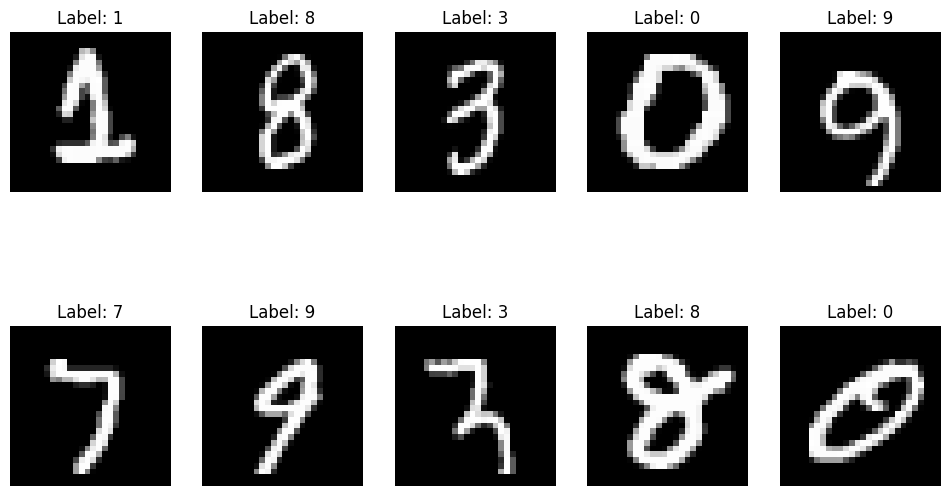

In [ ]:
# Extract a random sample of 10 images from the training dataset.
mnist_train_sample = mnist_train.sample(10)

# Plot the datasets
plt.figure(figsize=(12,7))
for i, (index, row) in enumerate(mnist_train_sample.iterrows()):
  plt.subplot(2, 5, i+1)
  plt.imshow(np.array(row[1:]).reshape(28, 28), cmap='gray')
  plt.axis('off')
  plt.title(f"Label: {row[0]}")
plt.show()

# Define a toy VGG convolutional neural network.

There are several types of layers we will use for this VGG. These are already part of the PyTorch library.



*   nn.Conv2d: convolutional layer
*   nn.ReLU: ReLU activation function
* nn.MaxPool2d pooling layer to the output
* nn.Dropout: apply dropout, typical probability applied is 0.5
* nn.Linear: fully connected layer

Recall that VGGNet in Simonyan-Zisserman's paper used small convolution filters (3 x 3 with stride 1) and pooling filters ( 2 x 2 with stride 2). It also uses a simple design rule whereby layers have the same number of filters for the same output feature map size. If a feature map size is halved in each dimension, the number of channels doubles. In the original VGG architecture, 11-19 weight layers are used. The configurations in the paper are labeled by letters, but today, the number of weights is how each configuration is remembered. For instance, VGG with 16 weight layers is known as VGG16. For this toy VGG, we will use fewer layers, as to not cause the training time to take too long.

The input will be a 28 x 28 pixel greyscale image.

In [ ]:

class ToyVGG(nn.Module):
    def __init__(self, num_classes=num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1), nn.ReLU(inplace=True), # Layer 1
            nn.Conv2d(32, 32, 3, stride=1, padding=1), nn.ReLU(inplace=True), # Layer 2
            nn.MaxPool2d(2, stride = 2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(inplace=True), # Layer 3
            nn.Conv2d(64, 64, 3, stride=1, padding=1), nn.ReLU(inplace=True), # Layer 4
        )

        self.classifier = nn.Sequential( # Fully connected layer
            nn.Flatten(),
            nn.Linear(64*14*14, 256), # Layer 5
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes), # Layer 6
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Hyperparameters & MNIST dataset transformations
Define the batch size, learning rate, and loss function for training.

Also, prepare the datasets for training through data augmentation, as done in AlexNet and VGG. Note that we choose a larger batch size of 500 to try to speed up the amount of time to train and a larger learning rate (0.01 instead of 0.001).

In [ ]:
# PyTorch has its own requirements for loading datasets. Use this to convert the
# Pandas dataframe into a dataset that can be loaded into the Conv2d layer.

class create_dataset(torch.utils.data.Dataset):
  def __init__(self, dataframe, transform=None):
    self.labels = dataframe.iloc[:,0].values
    self.images = dataframe.iloc[:,1:].values.astype('float32')
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image = self.images[idx].reshape(28, 28, 1) # reshape the 784 pixels to 28 x 28 x 1
    label = self.labels[idx]
    if self.transform:
      image = self.transform(image)
    return image, label

# Hyperparameters
epochs = 10
batch_size = 200
learning_rate = 0.01
loss_function = nn.CrossEntropyLoss()

transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize grayscale images according to mean and standard deviation of mnist
    # We had computed this before in one of the first few cells.
    transforms.Normalize((mean,), (std,))
])

# Apply previously written function to convert the Pandas dataframe.
train_dataset = create_dataset(mnist_train, transform=transform)
test_dataset = create_dataset(mnist_test, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training

This may take several minutes to run. Note that PyTorch has pre-trained models that can be used and may be more accurate due to the concept of transfer learning. The pre-trained models have already been trained on millions of images and thousands of categories, and knowledge from them can be fine-tuned for a specific task. We do not implement the pre-trained ones here, but we want to point out this is an option.

In [ ]:
# Initialize model
model = ToyVGG()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        images,labels = images.to(torch.float32), labels.to(torch.int64)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


Epoch [1/10], Step [1/300], Loss: 5.3431
Epoch [1/10], Step [2/300], Loss: 590.1125
Epoch [1/10], Step [3/300], Loss: 2.8453
Epoch [1/10], Step [4/300], Loss: 2.3042
Epoch [1/10], Step [5/300], Loss: 2.3046
Epoch [1/10], Step [6/300], Loss: 2.3070
Epoch [1/10], Step [7/300], Loss: 2.2975
Epoch [1/10], Step [8/300], Loss: 2.3024
Epoch [1/10], Step [9/300], Loss: 2.2990
Epoch [1/10], Step [10/300], Loss: 2.2989
Epoch [1/10], Step [11/300], Loss: 2.3046
Epoch [1/10], Step [12/300], Loss: 2.2943
Epoch [1/10], Step [13/300], Loss: 2.2894
Epoch [1/10], Step [14/300], Loss: 2.2736
Epoch [1/10], Step [15/300], Loss: 2.2488
Epoch [1/10], Step [16/300], Loss: 2.1926
Epoch [1/10], Step [17/300], Loss: 2.0731
Epoch [1/10], Step [18/300], Loss: 1.9722
Epoch [1/10], Step [19/300], Loss: 1.6397
Epoch [1/10], Step [20/300], Loss: 1.5601
Epoch [1/10], Step [21/300], Loss: 1.4274
Epoch [1/10], Step [22/300], Loss: 1.3955
Epoch [1/10], Step [23/300], Loss: 1.5291
Epoch [1/10], Step [24/300], Loss: 1.2632

KeyboardInterrupt: 

# Testing

Test the results of training.

In [ ]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(torch.float32), labels.to(torch.int64)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the network on the test images: {100 * correct / total}%')

Let's explore the accuracy when we apply skip connections.

# Apply residual learning

This time, we will make use of nn.BatchNorm2d for batch normalization, as was done in ResNet to help overcome problems with vanishing gradients. We will also define different "blocks" of layers within the class to implement skip connections/residual learning.

Note that this time we use nn.AdaptiveAvgPool2d for a more robust design. The classifier is now independent of the input image size.

In [ ]:
class ToyVGG_residual(nn.Module):
    def __init__(self, num_classes=num_classes):
        super().__init__()
        self.relu = nn.ReLU()

        # Initial convolution layer
        self.conv1 = nn.Conv2d(1, 32, 3, stride=1, padding=1)
        self.batchNorm = nn.BatchNorm2d(32)

        # Block 1: identity, input and output dimensions are the same
        self.block1_conv1 = nn.Conv2d(32, 32, 3, stride=1, padding=1)
        self.block1_batch1 = nn.BatchNorm2d(32)
        self.block1_conv2 = nn.Conv2d(32, 32, 3, stride=1, padding=1)
        self.block1_batch2 = nn.BatchNorm2d(32)

        # Block 2: halve the spatial dimensions by reducing the stride to 2
        # and doubling channels
        self.block2_conv1 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.block2_batch1 = nn.BatchNorm2d(64)
        self.block2_conv2 = nn.Conv2d(64, 64, 3, stride=1, padding=1)
        self.block2_batch2 = nn.BatchNorm2d(64)

        # Match dimensions for residual connection
        self.block2_residual = nn.Sequential(
            nn.Conv2d(32, 64, 1, stride=2),
            nn.BatchNorm2d(64)
        )

        # Block 3: identity
        self.block3_conv1 = nn.Conv2d(64, 64, 3, stride=1, padding=1)
        self.block3_batch1 = nn.BatchNorm2d(64)
        self.block3_conv2 = nn.Conv2d(64, 64, 3, stride=1, padding=1)
        self.block3_batch2 = nn.BatchNorm2d(64)


        self.classifier = nn.Sequential( # Fully connected layer
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    # Data flow with residual learning
    def forward(self, x):

        # Initial layer
        x = self.relu(self.batchNorm(self.conv1(x)))

        # Block 1 Residual block
        # Define some input x to use for skip connection
        residual = x
        out = self.relu(self.block1_batch1(self.block1_conv1(x)))
        out = self.relu(self.block1_batch2(self.block1_conv2(out)))
        out = out + residual
        x = self.relu(out)

        # Block 2
        # Pass skip connection
        residual = self.block2_residual(x)
        out = self.relu(self.block2_batch1(self.block2_conv1(x)))
        out = self.relu(self.block2_batch2(self.block2_conv2(out)))
        out = out + residual
        x = self.relu(out)

        # Block 3
        residual = x
        out = self.relu(self.block3_batch1(self.block3_conv1(x)))
        out = self.relu(self.block3_batch2(self.block3_conv2(out)))
        out = out + residual
        x = self.relu(out)

        # Classfier
        x = self.classifier(x)
        return x

Training loop, as done before.

In [ ]:
# Initialize model
model_residual = ToyVGG_residual()
optimizer = optim.Adam(model_residual.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(epochs):
    model_residual.train()
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        images,labels = images.to(torch.float32), labels.to(torch.int64)
        outputs = model_residual(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Testing loop.

In [ ]:
# Testing loop
model_residual.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(torch.float32), labels.to(torch.int64)
        outputs = model_residual(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct / total}%')

# Analysis

We can plot confusion matrices as one way to examine the outcomes of training and testing the 2 different models. We write functions to do so that way we can change the model input to compare the regular ToyVGG vs ToyVGG_residual models.

In [ ]:
def plot_confusion_matrix(model, model_name, test_loader):

  # Loop through model to extract predictions and labels
  all_predictions = []
  all_labels = []
  model.eval()
  with torch.no_grad():
      for images, labels in test_loader:
        images, labels = images.to(torch.float32), labels.to(torch.int64)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

  confusion_matrix_residual = confusion_matrix(all_labels, all_predictions)

  # Plot confusion matrix
  plt.figure(figsize=(10, 8))
  sns.heatmap(confusion_matrix_residual, annot=True, fmt='d', cmap='Blues', xticklabels=range(10)
  , yticklabels=range(10))
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title(f'Confusion Matrix for {model_name}')
  plt.show()


plot_confusion_matrix(model, 'ToyVGG', test_loader)
plot_confusion_matrix(model_residual, 'ToyVGG_residual', test_loader)

Examining the confusion matrices, we see that there are more errors when the true labels are 7 and 4, and predicted labels 2 and 9, respectively. These are numbers that can look similar, depending on the handwriting, so the misclassification makes sense. Acccuracy can be improved with deeper models, in which case transfer learning of a pre-trained model, as mentioned before, can be used if one does not have the time to train a large model from scratch. Otherwise, fine-tuning the hyperparameters can help too.

Congrats! You have learned how to load datasets, obtain their rescaled means and standard deviations for later normalization steps, build VGG models from scratch, train, test, and analyze them.